In [1]:
!pip install opencv-python imutils numpy matplotlib

In [6]:
import cv2
import numpy as np
import imutils
from imutils import contours
from imutils import perspective
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
uploaded = files.upload()

Saving ChatGPT Image Mar 30, 2026, 04_47_30 PM.png to ChatGPT Image Mar 30, 2026, 04_47_30 PM.png


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

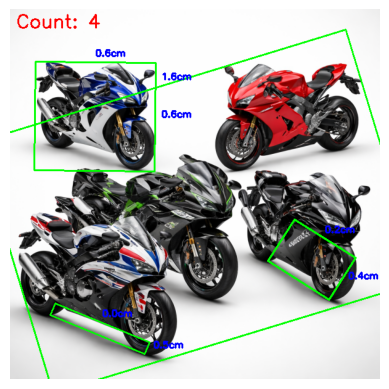

In [10]:

image = cv2.imread(list(uploaded.keys())[0])
orig = image.copy()

image = imutils.resize(image, width=600)


gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)
edged = cv2.Canny(blur, 50, 100)

edged = cv2.dilate(edged, None, iterations=1)
edged = cv2.erode(edged, None, iterations=1)

cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

(cnts, _) = contours.sort_contours(cnts)


pixelsPerMetric = None
object_count = 0

for c in cnts:
    if cv2.contourArea(c) < 100:
        continue

    object_count += 1

    box = cv2.minAreaRect(c)
    box = cv2.boxPoints(box)
    box = np.array(box, dtype="int")

    box = imutils.perspective.order_points(box)

    cv2.drawContours(image, [box.astype("int")], -1, (0, 255, 0), 2)

    (tl, tr, br, bl) = box
    mid_top = ((tl[0] + tr[0]) // 2, (tl[1] + tr[1]) // 2)
    mid_bottom = ((bl[0] + br[0]) // 2, (bl[1] + bl[1]) // 2)
    mid_left = ((tl[0] + bl[0]) // 2, (tl[1] + bl[1]) // 2)
    mid_right = ((tr[0] + br[0]) // 2, (tr[1] + br[1]) // 2)

    dA = np.linalg.norm(np.array(mid_top) - np.array(mid_bottom))
    dB = np.linalg.norm(np.array(mid_left) - np.array(mid_right))


    if pixelsPerMetric is None:
        pixelsPerMetric = dB / 2.0

    dimA = dA / pixelsPerMetric
    dimB = dB / pixelsPerMetric

    cv2.putText(image, "{:.1f}cm".format(dimA),
                (int(mid_top[0]), int(mid_top[1] - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    cv2.putText(image, "{:.1f}cm".format(dimB),
                (int(mid_right[0] + 10), int(mid_right[1])),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

cv2.putText(image, f"Count: {object_count}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")